In [139]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# Statistical modeling
import statsmodels.api as sm

# Ignore warnings (clean output)
import warnings
warnings.filterwarnings("ignore")

In [140]:
df = pd.read_csv("data/diabetes.csv")
# lot of missing values hence these columns are dropped
df = df.drop(columns = ['Insulin', 'SkinThickness'])
print(df.head())
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6      148             72  33.6                     0.627   50   
1            1       85             66  26.6                     0.351   31   
2            8      183             64  23.3                     0.672   32   
3            1       89             66  28.1                     0.167   21   
4            0      137             40  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFun

In [147]:
cols_with_zero = ["Glucose", "BloodPressure", "BMI"]

# Replace 0 with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())

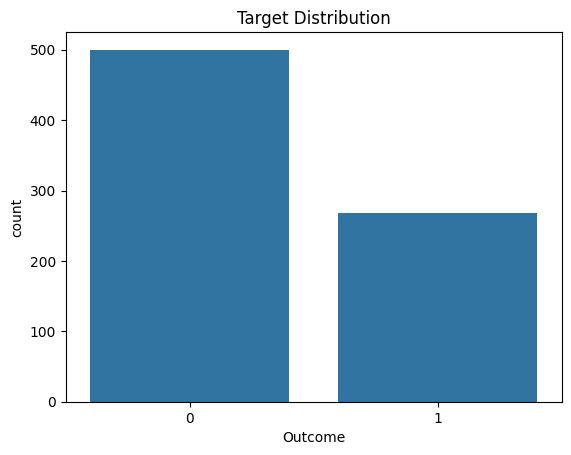

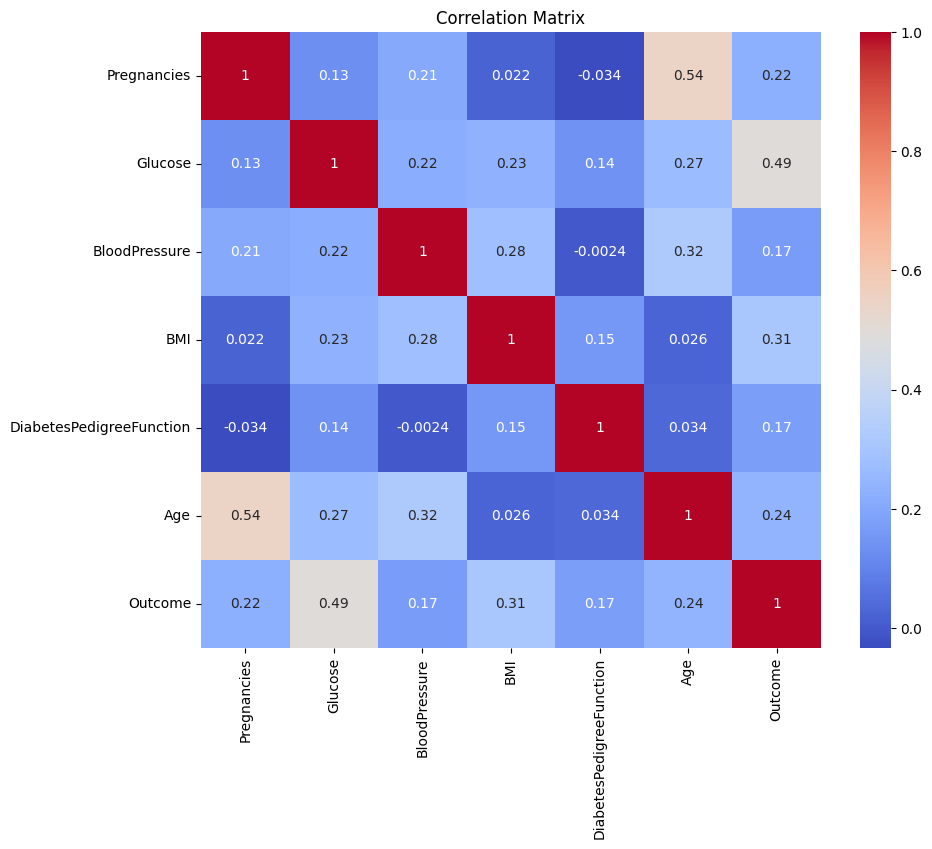

In [142]:
sns.countplot(x=df["Outcome"])
plt.title("Target Distribution")
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [143]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# stratify=y maintains class balance in train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [144]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coeff_df.sort_values(by="Coefficient", ascending=False))

                    Feature  Coefficient
1                   Glucose     1.155397
3                       BMI     0.693778
0               Pregnancies     0.375211
4  DiabetesPedigreeFunction     0.228964
5                       Age     0.152409
2             BloodPressure    -0.042058


In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.23886961809208726
y_pred_new = (y_prob >= threshold).astype(int)

# Computing Youden’s J statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
threshold = best_threshold



--- Numerical Comparison ---
   Metric  Threshold 0.5  Optimal (0.2389)
 Accuracy       0.701299          0.733766
Precision       0.590909          0.578313
   Recall       0.481481          0.888889
 F1 Score       0.530612          0.700730


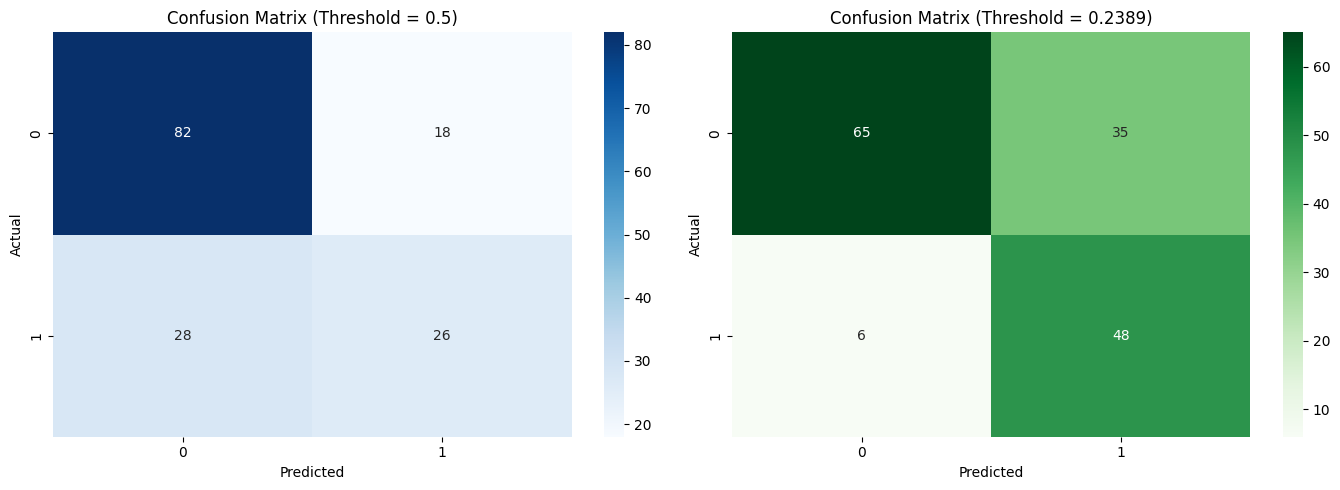

In [148]:
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Threshold 0.5": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    f"Optimal ({threshold:.4f})": [
        accuracy_score(y_test, y_pred_new),
        precision_score(y_test, y_pred_new),
        recall_score(y_test, y_pred_new),
        f1_score(y_test, y_pred_new)
    ]
}

df_results = pd.DataFrame(results)
print("\n--- Numerical Comparison ---")
print(df_results.to_string(index=False))

# Plotting Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard Threshold (0.5)
cm_old = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_old, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix (Threshold = 0.5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Optimal Threshold
cm_new = confusion_matrix(y_test, y_pred_new)
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Confusion Matrix (Threshold = {threshold:.4f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()